## 1. Cài đặt thư viện

In [1]:
!pip install contractions transformers -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.7 MB/s eta 0:00:00


## 2. Import thư viện

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, log_loss)

# TensorFlow / Keras (LSTM)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                      Bidirectional, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping

# PyTorch & HuggingFace (BERT)
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW # Corrected import for AdamW, using torch.optim
from tqdm import tqdm

print(f'TensorFlow: {tf.__version__}')
print(f'PyTorch   : {torch.__version__}')
print(f'GPU (TF)  : {tf.config.list_physical_devices("GPU")}')
print(f'GPU (PT)  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU name  : {torch.cuda.get_device_name(0)}')


TensorFlow: 2.20.0
PyTorch   : 2.10.0+cu128
GPU (TF)  : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU (PT)  : True
GPU name  : Tesla T4


## 3. Tải dữ liệu WELFake Dataset

In [3]:
from google.colab import drive

drive.mount('/content/drive')
%cd '/content/drive/MyDrive/Data_TL'
df=pd.read_csv('preprocessed_welfake.csv')
df.head(10)


Mounted at /content/drive
/content/drive/MyDrive/Data_TL


,title,text,label,language,punctuation_count,uppercase_ratio,numerical_count,sentiment_polarity,processed_title,processed_text,title_len,text_len,total_len,combined_processed_text,combined_text_title
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,en,182,0.031888,30,0.080000,"['law', 'enforcement', 'high', 'alert', 'follo...","['no_comment', 'expect', 'back', 'drama', 'mem...",130,5049,5179,"['law', 'enforcement', 'high', 'alert', 'follo...",LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,en,2,0.023148,0,0.121875,"['unbelievable', 'drama', 'attorney', 'general...","['demonstrator', 'gather', 'last', 'night', 'e...",137,216,353,"['unbelievable', 'drama', 'attorney', 'general...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,en,154,0.030712,34,0.000000,"['bobby', 'final', 'raise', 'hindu', 'us', 'st...","['dozen', 'politically', 'active', 'pastor', '...",105,8010,8115,"['bobby', 'final', 'raise', 'hindu', 'us', 'st...","Bobby Jindal, raised Hindu, uses story of Chri..."
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,en,42,0.064196,70,-0.287879,"['satan', 'russia', 'unvelis', 'image', 'terri...","['rs28', 'format', 'missile', 'dub', 'satan', ...",95,1916,2011,"['satan', 'russia', 'unvelis', 'image', 'terri...",SATAN 2: Russia unvelis an image of its terrif...
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,en,41,0.063399,0,-0.400000,"['time', 'christian', 'group', 'see', 'amazon'...","['say', 'one', 'time', 'someone', 'sue', 'sout...",78,1530,1608,"['time', 'christian', 'group', 'see', 'amazon'...",About Time! Christian Group Sues Amazon and SP...
5,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,DR. BEN CARSON TELLS THE STORY OF WHAT HAPPENE...,1,en,2,0.790123,0,0.000000,"['dr', 'ben', 'carson', 'target', 'irs', 'neve...","['dr', 'ben', 'carson', 'tell', 'story', 'happ...",105,81,186,"['dr', 'ben', 'carson', 'target', 'irs', 'neve...",DR BEN CARSON TARGETED BY THE IRS: “I never ha...
6,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,1,en,0,0.000000,0,-0.500000,"['house', 'inter', 'chair', 'trumprussia', 'fa...",[],79,1,80,"['house', 'inter', 'chair', 'trumprussia', 'fa...",HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...
7,Sports Bar Owner Bans NFL Games…Will Show Only...,"The owner of the Ringling Bar, located south o...",1,en,33,0.046560,0,0.087500,"['sport', 'bar', 'owner', 'bank', 'nl', 'games...","['owner', 'ring', 'bar', 'locate', 'south', 'w...",116,1439,1555,"['sport', 'bar', 'owner', 'bank', 'nl', 'games...",Sports Bar Owner Bans NFL Games…Will Show Only...
8,Latest Pipeline Leak Underscores Dangers Of Da...,"FILE – In this Sept. 15, 2005 file photo, the ...",1,en,90,0.041570,34,0.500000,[],"['file', 'sept', 'file', 'photo', 'marker', 'w...",66,3007,3073,"[]['file', 'sept', 'file', 'photo', 'marker', ...",Latest Pipeline Leak Underscores Dangers Of Da...
9,GOP Senator Just Smacked Down The Most Puncha...,The most punchable Alt-Right Nazi on the inter...,1,en,250,0.055995,121,0.172222,"['go', 'senator', 'smack', 'punchable', 'alrig...","['punchable', 'alright', 'nasi', 'internet', '...",80,4679,4759,"['go', 'senator', 'smack', 'punchable', 'alrig...",GOP Senator Just Smacked Down The Most Puncha...


## 4. Khám phá dữ liệu (EDA)

In [4]:
print('=== THÔNG TIN DATASET ===')
print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
print(f'\nGiá trị thiếu:')
print(df.isnull().sum())

# Clean the 'label' column by converting to numeric and dropping non-numeric labels
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

print(f'\n=== PHÂN PHỐI NHÃN ===')
print(df['label'].value_counts())
print(f'  Fake  : {df["label"].sum()/len(df)*100:.2f}%')
print(f'  Real  : {(1-df["label"].mean())*100:.2f}%')


=== THÔNG TIN DATASET ===
Shape   : (71537, 15)
Columns : ['title', 'text', 'label', 'language', 'punctuation_count', 'uppercase_ratio', 'numerical_count', 'sentiment_polarity', 'processed_title', 'processed_text', 'title_len', 'text_len', 'total_len', 'combined_processed_text', 'combined_text_title']

Giá trị thiếu:
title                      0
text                       0
label                      0
language                   0
punctuation_count          0
uppercase_ratio            0
numerical_count            0
sentiment_polarity         0
processed_title            0
processed_text             0
title_len                  0
text_len                   0
total_len                  0
combined_processed_text    0
combined_text_title        0
dtype: int64

=== PHÂN PHỐI NHÃN ===
label
1    36509
0    35028
Name: count, dtype: int64
  Fake  : 51.04%
  Real  : 48.96%


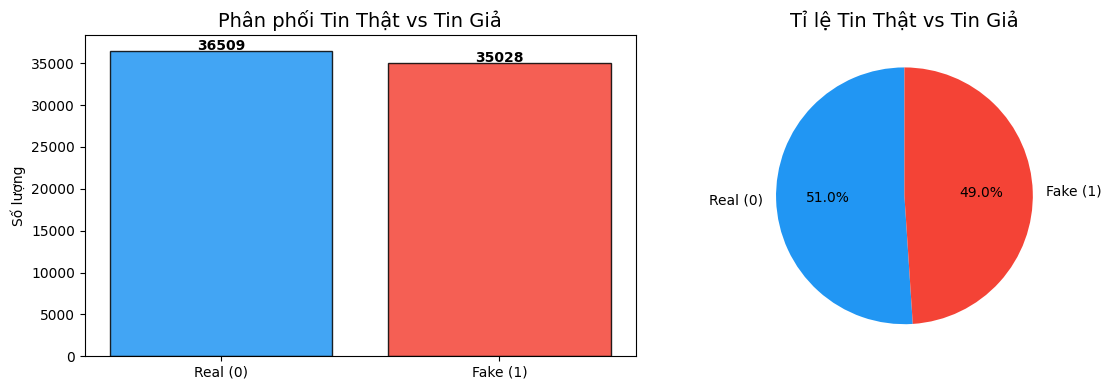

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts = df['label'].value_counts()

axes[0].bar(['Real (0)', 'Fake (1)'], label_counts.values,
            color=['#2196F3', '#F44336'], alpha=0.85, edgecolor='black')
axes[0].set_title('Phân phối Tin Thật vs Tin Giả', fontsize=14)
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=['Real (0)', 'Fake (1)'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Tỉ lệ Tin Thật vs Tin Giả', fontsize=14)

plt.tight_layout()
plt.show()


## 5. Tiền xử lý dữ liệu

In [6]:
df.drop('Unnamed: 0', axis=1, errors='ignore', inplace=True)
df.dropna(subset=['title', 'text'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Kết hợp title + text
df['combined'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

print(f'Dataset sau xử lý: {df.shape}')
df.head(3)


Dataset sau xử lý: (71537, 16)


,title,text,label,language,punctuation_count,uppercase_ratio,numerical_count,sentiment_polarity,processed_title,processed_text,title_len,text_len,total_len,combined_processed_text,combined_text_title,combined
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,en,182,0.031888,30,0.080000,"['law', 'enforcement', 'high', 'alert', 'follo...","['no_comment', 'expect', 'back', 'drama', 'mem...",130,5049,5179,"['law', 'enforcement', 'high', 'alert', 'follo...",LAW ENFORCEMENT ON HIGH ALERT Following Threat...,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,en,2,0.023148,0,0.121875,"['unbelievable', 'drama', 'attorney', 'general...","['demonstrator', 'gather', 'last', 'night', 'e...",137,216,353,"['unbelievable', 'drama', 'attorney', 'general...",UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,en,154,0.030712,34,0.000000,"['bobby', 'final', 'raise', 'hindu', 'us', 'st...","['dozen', 'politically', 'active', 'pastor', '...",105,8010,8115,"['bobby', 'final', 'raise', 'hindu', 'us', 'st...","Bobby Jindal, raised Hindu, uses story of Chri...","Bobby Jindal, raised Hindu, uses story of Chri..."


In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Làm sạch và chuẩn hoá văn bản tiếng Anh."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # Xóa URL
    text = re.sub(r'<.*?>', '', text)                       # Xóa HTML
    text = re.sub(r'[^a-z\s]', '', text)                   # Xóa số & ký tự đặc biệt
    words = [lemmatizer.lemmatize(w) for w in text.split()
             if w not in stop_words and len(w) > 2]
    return ' '.join(words)

print('Đang làm sạch văn bản... (khoảng 2–5 phút)')
df['cleaned_text'] = df['combined'].apply(clean_text)
print('Hoàn thành!')
print(f'\nVí dụ gốc     : {df["combined"].iloc[0][:150]}')
print(f'Ví dụ đã sạch  : {df["cleaned_text"].iloc[0][:150]}')


Đang làm sạch văn bản... (khoảng 2–5 phút)
Hoàn thành!

Ví dụ gốc     : LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expec
Ví dụ đã sạch  : law enforcement high alert following threat cop white blacklivesmatter fyf terrorist video comment expected barack obama member fyf fukyoflag blackliv


## 6. Chia tập dữ liệu – Train / Validation / Test



In [8]:
X = df['cleaned_text']
y = df['label']

# ── Bước 1: 70% train | 30% temp (val + test) ──────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ── Bước 2: chia temp thành 50/50 → val = 15%, test = 15% ─────────────────
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

total = len(X)
print('=' * 48)
print('       PHÂN CHIA TẬP DỮ LIỆU')
print('=' * 48)
print(f'  Tổng số mẫu  : {total:,}')
print(f'  Train        : {len(X_train):,} mẫu  ({len(X_train)/total*100:.1f}%)')
print(f'  Validation   : {len(X_val):,}  mẫu  ({len(X_val)/total*100:.1f}%)')
print(f'  Test         : {len(X_test):,}  mẫu  ({len(X_test)/total*100:.1f}%)')
print('=' * 48)
print(f'  y_train : {y_train.value_counts().to_dict()}')
print(f'  y_val   : {y_val.value_counts().to_dict()}')
print(f'  y_test  : {y_test.value_counts().to_dict()}')


       PHÂN CHIA TẬP DỮ LIỆU
  Tổng số mẫu  : 71,537
  Train        : 50,075 mẫu  (70.0%)
  Validation   : 10,731  mẫu  (15.0%)
  Test         : 10,731  mẫu  (15.0%)
  y_train : {1: 25556, 0: 24519}
  y_val   : {1: 5477, 0: 5254}
  y_test  : {1: 5476, 0: 5255}


## 7. Trích xuất đặc trưng TF-IDF (cho Random Forest & SVM)

In [9]:
print('Đang tạo TF-IDF features...')
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

# Fit CHỈ trên train, transform cả 3 tập
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF (train) : {X_train_tfidf.shape}')
print(f'TF-IDF (val)   : {X_val_tfidf.shape}')
print(f'TF-IDF (test)  : {X_test_tfidf.shape}')


Đang tạo TF-IDF features...
TF-IDF (train) : (50075, 50000)
TF-IDF (val)   : (10731, 50000)
TF-IDF (test)  : (10731, 50000)


---
## Random Forest

In [10]:
print('=' * 60)
print('MÔ HÌNH 1: RANDOM FOREST')
print('=' * 60)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=50,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
print('Đang huấn luyện Random Forest...')
rf_model.fit(X_train_tfidf, y_train)
print('Hoàn thành!')


MÔ HÌNH 1: RANDOM FOREST
Đang huấn luyện Random Forest...
Hoàn thành!



📊 KẾT QUẢ RANDOM FOREST (Test Set):
  Accuracy : 0.9430  (94.30%)
  Log Loss : 0.3206

  Classification Report:
              precision    recall  f1-score   support

        Real       0.95      0.93      0.94      5255
        Fake       0.93      0.96      0.94      5476

    accuracy                           0.94     10731
   macro avg       0.94      0.94      0.94     10731
weighted avg       0.94      0.94      0.94     10731



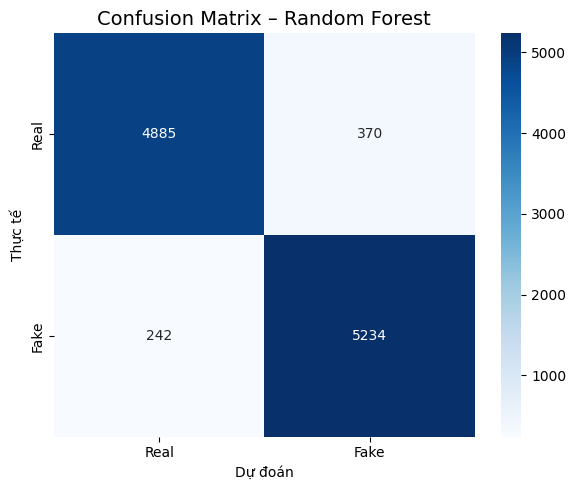

In [11]:
# Đánh giá trên tập TEST
y_pred_rf = rf_model.predict(X_test_tfidf)
y_prob_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]

rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_loss = log_loss(y_test, y_prob_rf)

print(f'\n📊 KẾT QUẢ RANDOM FOREST (Test Set):')
print(f'  Accuracy : {rf_acc:.4f}  ({rf_acc*100:.2f}%)')
print(f'  Log Loss : {rf_loss:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Real', 'Fake']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix – Random Forest', fontsize=14)
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán')
plt.tight_layout(); plt.show()


---
## MÔ HÌNH 2: SVM (Support Vector Machine)

In [12]:
print('=' * 60)
print('MÔ HÌNH 2: SVM (Support Vector Machine)')
print('=' * 60)

svm_base  = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(svm_base, cv=3)  # thêm predict_proba

print('Đang huấn luyện SVM...')
svm_model.fit(X_train_tfidf, y_train)
print('Hoàn thành!')


MÔ HÌNH 2: SVM (Support Vector Machine)
Đang huấn luyện SVM...
Hoàn thành!



📊 KẾT QUẢ SVM (Test Set):
  Accuracy : 0.9774  (97.74%)
  Log Loss : 0.0678

  Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.97      0.98      5255
        Fake       0.97      0.98      0.98      5476

    accuracy                           0.98     10731
   macro avg       0.98      0.98      0.98     10731
weighted avg       0.98      0.98      0.98     10731



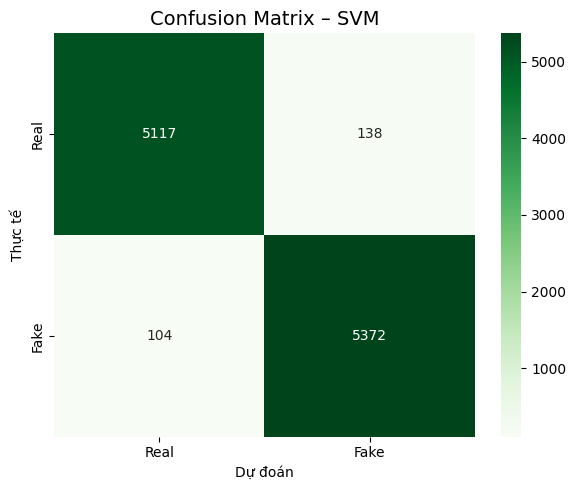

In [13]:
# Đánh giá trên tập TEST
y_pred_svm = svm_model.predict(X_test_tfidf)
y_prob_svm = svm_model.predict_proba(X_test_tfidf)[:, 1]

svm_acc  = accuracy_score(y_test, y_pred_svm)
svm_loss = log_loss(y_test, y_prob_svm)

print(f'\n📊 KẾT QUẢ SVM (Test Set):')
print(f'  Accuracy : {svm_acc:.4f}  ({svm_acc*100:.2f}%)')
print(f'  Log Loss : {svm_loss:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, y_pred_svm, target_names=['Real', 'Fake']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix – SVM', fontsize=14)
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán')
plt.tight_layout(); plt.show()


---
## MÔ HÌNH 3: LSTM (Long Short-Term Memory)

In [14]:
print('=' * 60)
print('MÔ HÌNH 3: LSTM')
print('=' * 60)

VOCAB_SIZE = 30000
MAX_LEN    = 300
EMBED_DIM  = 128
LSTM_UNITS = 128
BATCH_SIZE = 64
EPOCHS     = 10

# Tokenize – fit CHỈ trên train
print('Đang tokenize văn bản...')
tokenizer_lstm = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_train)

X_train_seq = tokenizer_lstm.texts_to_sequences(X_train)
X_val_seq   = tokenizer_lstm.texts_to_sequences(X_val)
X_test_seq  = tokenizer_lstm.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'X_train_pad : {X_train_pad.shape}')
print(f'X_val_pad   : {X_val_pad.shape}')
print(f'X_test_pad  : {X_test_pad.shape}')


MÔ HÌNH 3: LSTM
Đang tokenize văn bản...
X_train_pad : (50075, 300)
X_val_pad   : (10731, 300)
X_test_pad  : (10731, 300)


In [15]:
def build_lstm_model(vocab_size, embed_dim, lstm_units, max_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        # XOÁ recurrent_dropout=0.3 ở 2 layer LSTM dưới đây
        Bidirectional(LSTM(lstm_units, dropout=0.3, return_sequences=True)),
        Bidirectional(LSTM(lstm_units // 2, dropout=0.3)),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [16]:
from tensorflow.keras.callbacks import EarlyStopping

# Khởi tạo mô hình LSTM
lstm_model = build_lstm_model(VOCAB_SIZE, EMBED_DIM, LSTM_UNITS, MAX_LEN)
lstm_model.summary()

# Huấn luyện LSTM – validation_data dùng X_val_pad (val set thực sự)
print('Đang huấn luyện LSTM...')
early_stop = EarlyStopping(monitor='val_accuracy', patience=3,
                            restore_best_weights=True, verbose=1)

history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),   # ← val set riêng biệt (15%)
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
print('Hoàn thành huấn luyện LSTM!')


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Đang huấn luyện LSTM...
Epoch 1/10
783/783 ━━━━━━━━━━━━━━━━━━━━ 64s 67ms/step - accuracy: 0.9423 - loss: 0.1517 - val_accuracy: 0.9590 - val_loss: 0.1070
Epoch 2/10
783/783 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.9822 - loss: 0.0553 - val_accuracy: 0.9622 - val_loss: 0.1268
Epoch 3/10
783/783 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step - accuracy: 0.9919 - loss: 0.0238 - val_accuracy: 0.9637 - val_loss: 0.1493
Epoch 4/10
783/783 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.9959 - loss: 0.0133 - val_accuracy: 0.9595 - val_loss: 0.1397
Epoch 5/10
783/783 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.9966 - loss: 0.0098 - val_accuracy: 0.9655 - val_loss: 0.1489
Epoch 6/10
783/783 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step - accuracy: 0.9968 - loss: 0.0099 - val_accuracy: 0.9624 - val_loss: 0.1915
Epoch 7/10
783/783 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.9981 - loss: 0.0061 - val_accuracy: 0.9622 - val_loss: 0.2164
Epoch 8/10
783/783 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - accuracy: 

168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step

📊 KẾT QUẢ LSTM (Test Set):
  Accuracy : 0.9673  (96.73%)
  Log Loss : 0.1648

  Classification Report:
              precision    recall  f1-score   support

        Real       0.98      0.95      0.97      5255
        Fake       0.96      0.98      0.97      5476

    accuracy                           0.97     10731
   macro avg       0.97      0.97      0.97     10731
weighted avg       0.97      0.97      0.97     10731



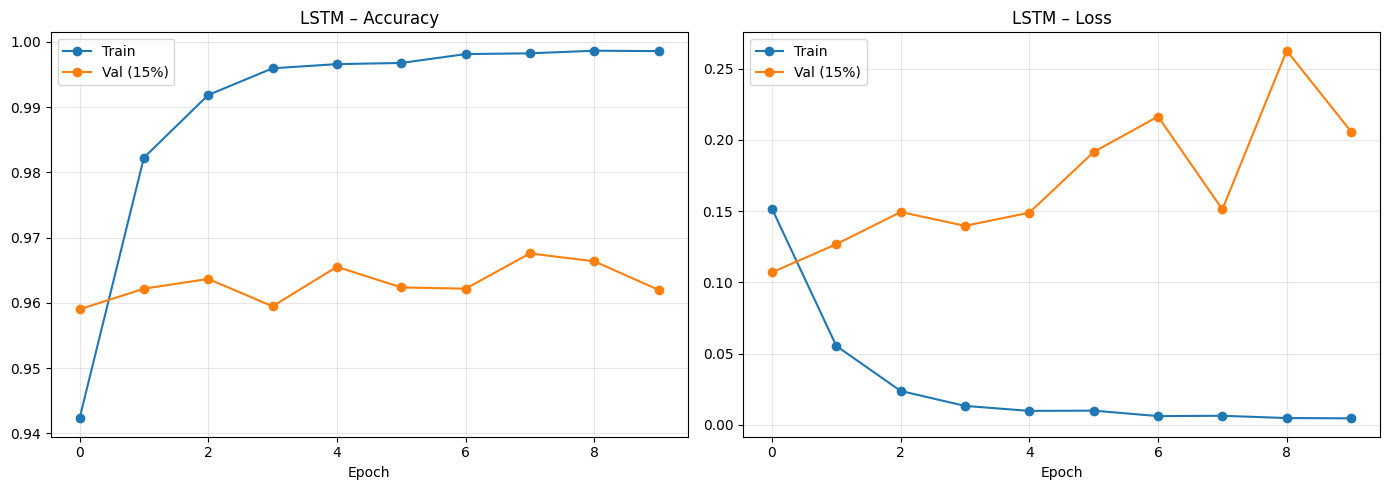

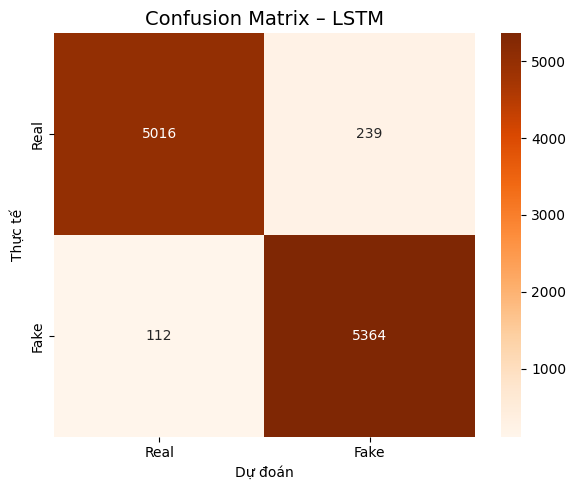

In [17]:
# Đánh giá LSTM trên tập TEST
y_prob_lstm = lstm_model.predict(X_test_pad, batch_size=BATCH_SIZE).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

lstm_acc  = accuracy_score(y_test, y_pred_lstm)
lstm_loss = log_loss(y_test, y_prob_lstm)

print(f'\n📊 KẾT QUẢ LSTM (Test Set):')
print(f'  Accuracy : {lstm_acc:.4f}  ({lstm_acc*100:.2f}%)')
print(f'  Log Loss : {lstm_loss:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_test, y_pred_lstm, target_names=['Real', 'Fake']))

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'],     label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val (15%)', marker='o')
axes[0].set_title('LSTM – Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Val (15%)', marker='o')
axes[1].set_title('LSTM – Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix – LSTM', fontsize=14)
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán')
plt.tight_layout(); plt.show()


---
## MÔ HÌNH 4: BERT (bert-base-uncased)

> ⚠️ **Bật GPU trước:** `Runtime → Change runtime type → T4 GPU`

In [18]:
import torch

print('=' * 60)
print('MÔ HÌNH 4: BERT')
print('=' * 60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️ Không có GPU – BERT sẽ rất chậm!')


MÔ HÌNH 4: BERT
Device: cuda
GPU: Tesla T4


In [19]:
BERT_MODEL_NAME = 'bert-base-uncased'
BERT_MAX_LEN    = 256
BERT_BATCH      = 16
BERT_EPOCHS     = 3
BERT_LR         = 2e-5

# Dùng raw text để BERT khai thác ngữ cảnh tốt hơn
X_train_bert = df.loc[X_train.index, 'combined'].values
X_val_bert   = df.loc[X_val.index,   'combined'].values
X_test_bert  = df.loc[X_test.index,  'combined'].values
y_train_bert = y_train.values
y_val_bert   = y_val.values
y_test_bert  = y_test.values

print('Đang tải BERT tokenizer...')
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
print('Tải xong!')


Đang tải BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tải xong!


In [20]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

# 3 DataLoader: train / val / test
train_ds = NewsDataset(X_train_bert, y_train_bert, bert_tokenizer, BERT_MAX_LEN)
val_ds   = NewsDataset(X_val_bert,   y_val_bert,   bert_tokenizer, BERT_MAX_LEN)
test_ds  = NewsDataset(X_test_bert,  y_test_bert,  bert_tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BERT_BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BERT_BATCH, shuffle=False)

print(f'Số batch train : {len(train_loader):,}')
print(f'Số batch val   : {len(val_loader):,}')
print(f'Số batch test  : {len(test_loader):,}')


Số batch train : 3,130
Số batch val   : 671
Số batch test  : 671


In [21]:
bert_model = BertForSequenceClassification.from_pretrained(BERT_MODEL_NAME, num_labels=2)
bert_model = bert_model.to(device)
optimizer_bert = AdamW(bert_model.parameters(), lr=BERT_LR, eps=1e-8, weight_decay=0.01)

# Learning rate scheduler
total_steps = len(train_loader) * BERT_EPOCHS
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)
print('Model BERT và Scheduler đã sẵn sàng!')


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model BERT và Scheduler đã sẵn sàng!


In [22]:
def train_bert_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, total_correct = 0, 0
    for batch in tqdm(loader, desc='Training', leave=False):
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        lbls  = batch['label'].to(device)
        optimizer.zero_grad()
        out   = model(input_ids=ids, attention_mask=mask, labels=lbls)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss    += out.loss.item()
        total_correct += (torch.argmax(out.logits, 1) == lbls).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)

def eval_bert(model, loader, device):
    model.eval()
    total_loss, total_correct = 0, 0
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            lbls = batch['label'].to(device)
            out  = model(input_ids=ids, attention_mask=mask, labels=lbls)
            total_loss    += out.loss.item()
            probs = torch.softmax(out.logits, 1)[:, 1]
            preds = torch.argmax(out.logits, 1)
            total_correct += (preds == lbls).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
    return (total_loss / len(loader),
            total_correct / len(loader.dataset),
            np.array(all_preds), np.array(all_probs), np.array(all_labels))


In [23]:
# Huấn luyện BERT – val_loader dùng val set (15%)
print(f'Bắt đầu huấn luyện BERT ({BERT_EPOCHS} epochs)...')
hist_bert = {'tr_loss':[], 'tr_acc':[], 'val_loss':[], 'val_acc':[]}

best_val_loss = float('inf')
BERT_SAVE_PATH = '/content/drive/MyDrive/Final_english_full/bert_model'
BERT_TOKENIZER_SAVE_PATH = '/content/drive/MyDrive/Final_english_full/bert_tokenizer'

for ep in range(BERT_EPOCHS):
    print(f'\n--- Epoch {ep+1}/{BERT_EPOCHS} ---')
    tl, ta = train_bert_epoch(bert_model, train_loader, optimizer_bert, scheduler_bert, device)
    vl, va, _, _, _ = eval_bert(bert_model, val_loader, device)
    hist_bert['tr_loss'].append(tl);  hist_bert['tr_acc'].append(ta)
    hist_bert['val_loss'].append(vl); hist_bert['val_acc'].append(va)
    print(f'  Train → Loss: {tl:.4f} | Acc: {ta:.4f}')
    print(f'  Val   → Loss: {vl:.4f} | Acc: {va:.4f}')

    # Save the best model based on validation loss
    if vl < best_val_loss:
        best_val_loss = vl
        bert_model.save_pretrained(BERT_SAVE_PATH)
        bert_tokenizer.save_pretrained(BERT_TOKENIZER_SAVE_PATH)
        print(f"  💾 Saved best model checkpoint with Val Loss: {vl:.4f}")

print('\n✅ Hoàn thành huấn luyện BERT!')


Bắt đầu huấn luyện BERT (3 epochs)...

--- Epoch 1/3 ---


  Train → Loss: 0.0912 | Acc: 0.9653
  Val   → Loss: 0.0238 | Acc: 0.9932


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 Saved best model checkpoint with Val Loss: 0.0238

--- Epoch 2/3 ---


  Train → Loss: 0.0158 | Acc: 0.9964
  Val   → Loss: 0.0257 | Acc: 0.9950

--- Epoch 3/3 ---


  Train → Loss: 0.0024 | Acc: 0.9995
  Val   → Loss: 0.0243 | Acc: 0.9956

✅ Hoàn thành huấn luyện BERT!


Loading best BERT model checkpoint...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


📊 KẾT QUẢ BERT (Test Set):
  Accuracy : 0.9939  (99.39%)
  Log Loss : 0.0213

  Classification Report:
              precision    recall  f1-score   support

        Real       1.00      0.99      0.99      5255
        Fake       0.99      1.00      0.99      5476

    accuracy                           0.99     10731
   macro avg       0.99      0.99      0.99     10731
weighted avg       0.99      0.99      0.99     10731



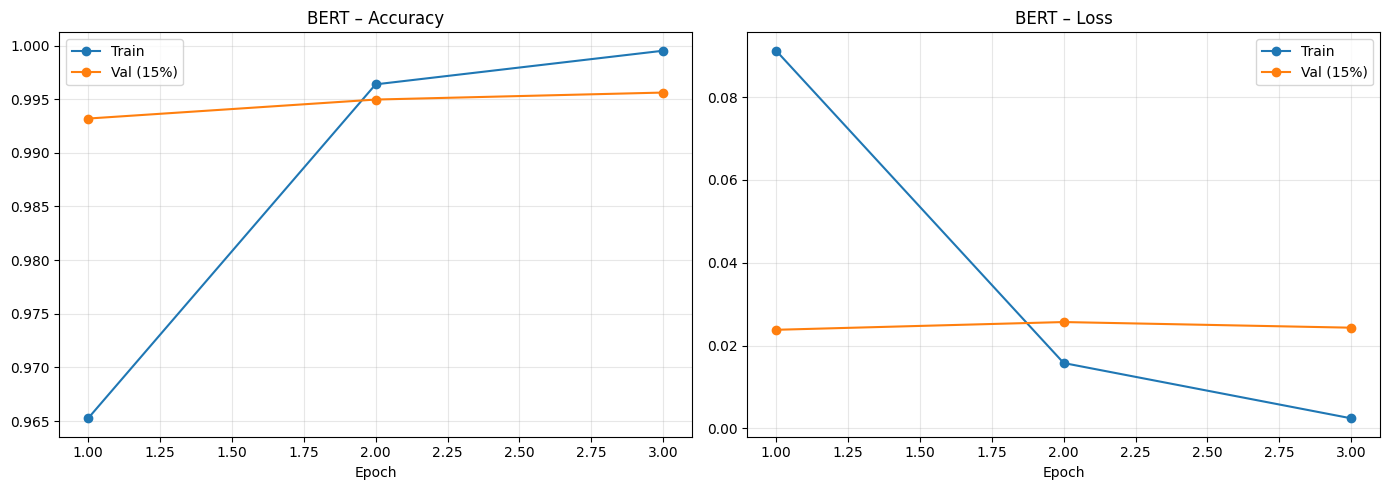

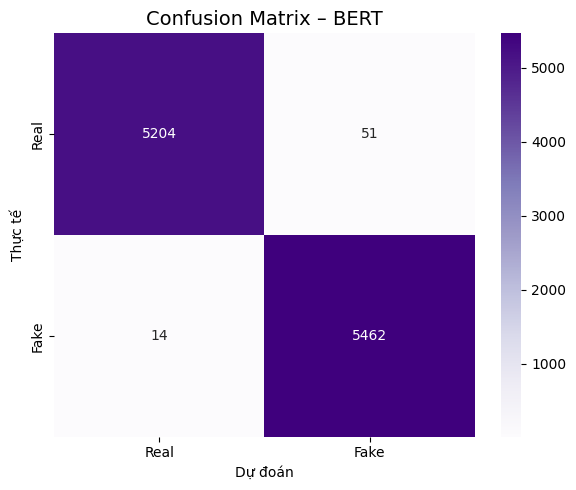

In [24]:
# Đánh giá BERT trên tập TEST
# Load the best model checkpoint before evaluating
print('Loading best BERT model checkpoint...')
best_bert_model = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/Data_TL/saved_models/bert_model')
best_bert_model = best_bert_model.to(device)

_, _, y_pred_bert, y_prob_bert, y_true_bert = eval_bert(
    best_bert_model, test_loader, device)

bert_acc  = accuracy_score(y_true_bert, y_pred_bert)
bert_loss = log_loss(y_true_bert, y_prob_bert)

print(f'\n📊 KẾT QUẢ BERT (Test Set):')
print(f'  Accuracy : {bert_acc:.4f}  ({bert_acc*100:.2f}%)')
print(f'  Log Loss : {bert_loss:.4f}')
print(f'\n  Classification Report:')
print(classification_report(y_true_bert, y_pred_bert, target_names=['Real', 'Fake']))

# Learning curves BERT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep_range = range(1, BERT_EPOCHS + 1)
axes[0].plot(ep_range, hist_bert['tr_acc'],  label='Train', marker='o')
axes[0].plot(ep_range, hist_bert['val_acc'], label='Val (15%)', marker='o')
axes[0].set_title('BERT – Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, hist_bert['tr_loss'],  label='Train', marker='o')
axes[1].plot(ep_range, hist_bert['val_loss'], label='Val (15%)', marker='o')
axes[1].set_title('BERT – Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

cm_bert = confusion_matrix(y_true_bert, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix – BERT', fontsize=14)
plt.ylabel('Thực tế'); plt.xlabel('Dự đoán')
plt.tight_layout(); plt.show()


---
## 8. So sánh hiệu suất các mô hình (trên Test Set)

In [25]:
models  = ['Random Forest', 'SVM', 'LSTM', 'BERT']
accs    = [rf_acc, svm_acc, lstm_acc, bert_acc]
losses  = [rf_loss, svm_loss, lstm_loss, bert_loss]
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

results_df = pd.DataFrame({
    'Mô hình'      : models,
    'Accuracy (%)'  : [f'{a*100:.2f}%' for a in accs],
    'Log Loss'      : [f'{l:.4f}' for l in losses]
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
results_df.index += 1

print('\n' + '=' * 50)
print('   BẢNG SO SÁNH HIỆU SUẤT (Test Set 15%)')
print('=' * 50)
print(results_df.to_string())
print('=' * 50)



   BẢNG SO SÁNH HIỆU SUẤT (Test Set 15%)
         Mô hình Accuracy (%) Log Loss
1           BERT       99.39%   0.0213
2            SVM       97.74%   0.0678
3           LSTM       96.73%   0.1648
4  Random Forest       94.30%   0.3206


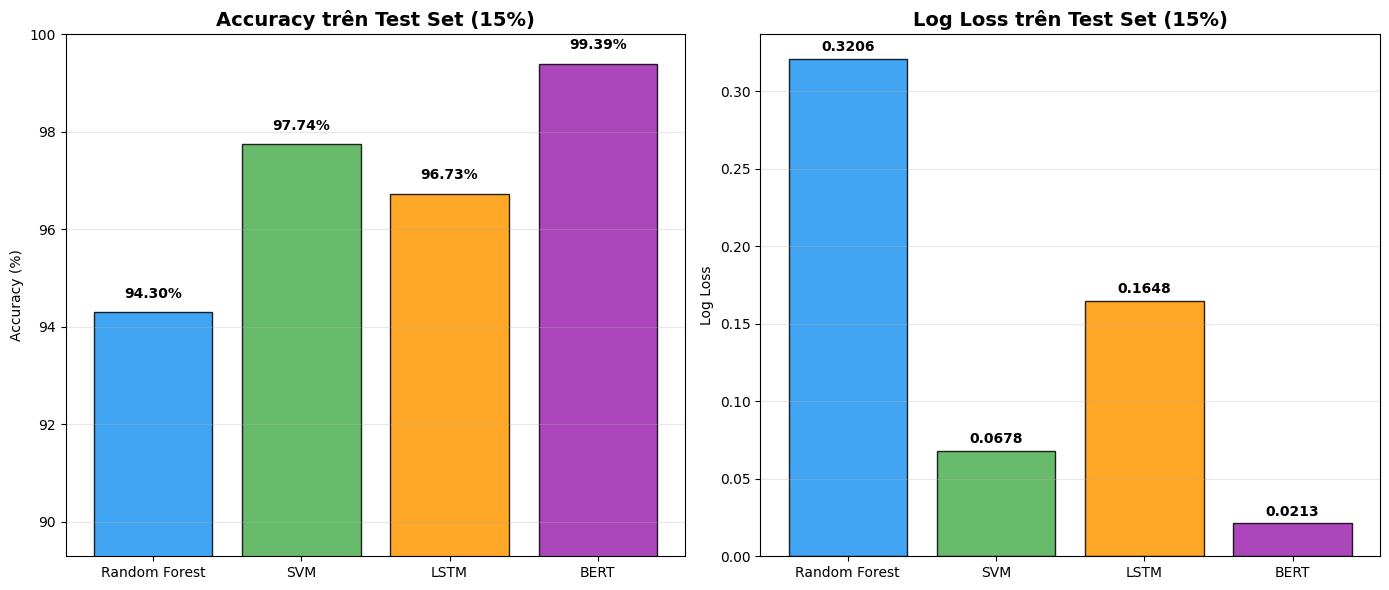

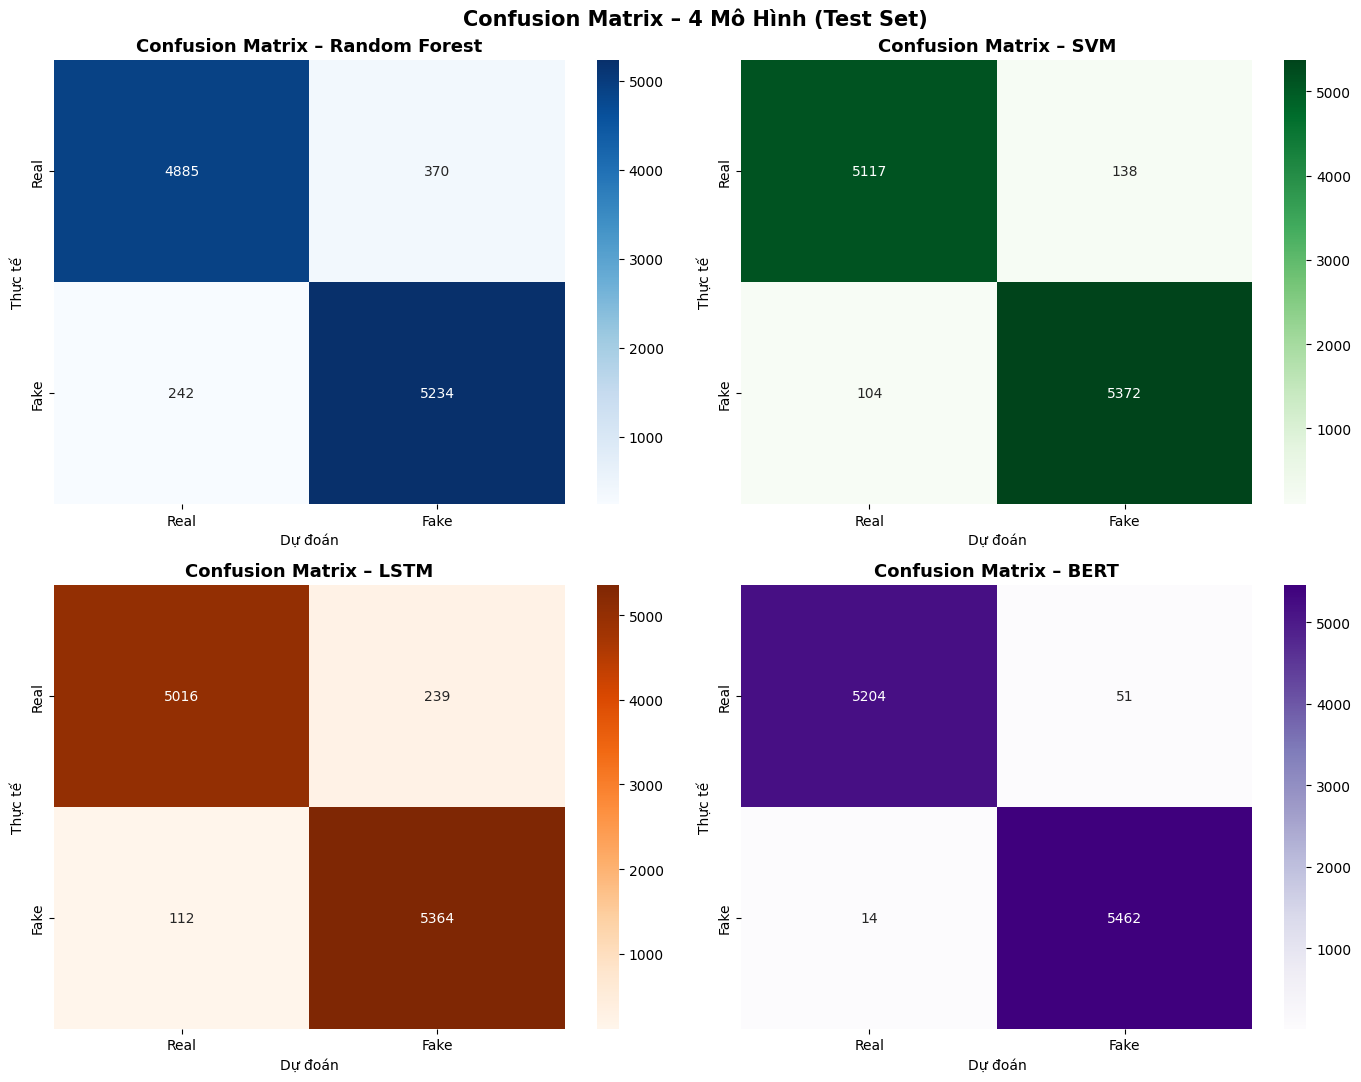

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy
bars1 = axes[0].bar(models, [a*100 for a in accs],
                    color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Accuracy trên Test Set (15%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([min(accs)*100 - 5, 100])
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc*100:.2f}%', ha='center', fontweight='bold')

# Log Loss
bars2 = axes[1].bar(models, losses, color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('Log Loss trên Test Set (15%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Loss')
axes[1].grid(axis='y', alpha=0.3)
for bar, loss in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{loss:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Data_TL/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 4 Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()
cms   = [cm_rf, cm_svm, cm_lstm, cm_bert]
titls = ['Random Forest', 'SVM', 'LSTM', 'BERT']
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples']
for ax, cm, t, c in zip(axes, cms, titls, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=c, ax=ax,
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
    ax.set_title(f'Confusion Matrix – {t}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Thực tế'); ax.set_xlabel('Dự đoán')
plt.suptitle('Confusion Matrix – 4 Mô Hình (Test Set)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Data_TL/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Lưu mô hình (tuỳ chọn)

In [27]:
import pickle, os
drive_models_dir = '/content/drive/MyDrive/Final_english_full'
os.makedirs(drive_models_dir, exist_ok=True)

print("💾 Đang lưu các mô hình vào Google Drive...")

with open(f'{drive_models_dir}/tfidf.pkl', 'wb') as f: pickle.dump(tfidf, f)
print("   ✅ tfidf.pkl")

with open(f'{drive_models_dir}/rf_model.pkl', 'wb') as f: pickle.dump(rf_model, f)
print("   ✅ rf_model.pkl")

with open(f'{drive_models_dir}/svm_model.pkl', 'wb') as f: pickle.dump(svm_model, f)
print("   ✅ svm_model.pkl")

lstm_model.save(f'{drive_models_dir}/lstm_model.keras')
with open(f'{drive_models_dir}/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer_lstm, f)
print("   ✅ lstm_model.keras")
print("   ✅ lstm_tokenizer.pkl")

# Note: BERT model and tokenizer were already saved to /content/drive/MyDrive/Final_english_full/bert_model during training
print(f'\n✅ Đã lưu tất cả các mô hình thành công vào Google Drive: {drive_models_dir}')


💾 Đang lưu các mô hình vào Google Drive...
   ✅ tfidf.pkl
   ✅ rf_model.pkl
   ✅ svm_model.pkl
   ✅ lstm_model.keras
   ✅ lstm_tokenizer.pkl

✅ Đã lưu tất cả các mô hình thành công vào Google Drive: /content/drive/MyDrive/Data_TL/saved_models


## 10. Tóm tắt kết quả

In [28]:
print('\n' + '=' * 65)
print('         TỔNG KẾT – HỆ THỐNG PHÁT HIỆN TIN GIẢ')
print('=' * 65)
print(f'  Dataset : WELFake (tiếng Anh)')

print(f'  {"Mô hình":<20} {"Accuracy":>12} {"Log Loss":>12}')
print('-' * 65)
for m, a, l in zip(models, accs, losses):
    print(f'  {m:<20} {a*100:>10.2f}% {l:>12.4f}')
print('-' * 65)
best = models[int(np.argmax(accs))]
print(f'  🏆 Tốt nhất: {best}  →  {max(accs)*100:.2f}%')
print('=' * 65)



         TỔNG KẾT – HỆ THỐNG PHÁT HIỆN TIN GIẢ
  Dataset : WELFake (tiếng Anh)
  Mô hình                  Accuracy     Log Loss
-----------------------------------------------------------------
  Random Forest             94.30%       0.3206
  SVM                       97.74%       0.0678
  LSTM                      96.73%       0.1648
  BERT                      99.39%       0.0213
-----------------------------------------------------------------
  🏆 Tốt nhất: BERT  →  99.39%
